In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [14]:
df = pd.read_csv('./data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
# CustomerID 제거, 성별 인코딩
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X = df[features].values

In [16]:
# Gender 다시 0/1로 복구
df = pd.read_csv('./data/Mall_Customers.csv')

df['Gender'] = (df['Gender'] == 'Male').astype(int)

In [17]:
# StandardScaler로 x 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DataFrame 형태로 보기
import pandas as pd
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [18]:
X_scaled_df

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


In [19]:
# 1️⃣ Gender는 0/1 유지
df['Gender'] = df['Gender'].round().astype(int)

# 2️⃣ 연속형 변수만 선택
num_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

# 3️⃣ Gender는 그대로 두고 최종 X 만들기
columns = num_features + ['Gender']
X = df[columns].values

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,-1.424569,-1.738999,-0.434801
1,2,1,-1.281035,-1.738999,1.195704
2,3,0,-1.352802,-1.700830,-1.715913
3,4,0,-1.137502,-1.700830,1.040418
4,5,0,-0.563369,-1.662660,-0.395980


In [20]:
# PCA : 2개의 주성분으로 압축
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# DataFrame으로 보기
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_df.head()

,PC1,PC2
0,-0.615720,-1.763481
1,-1.665793,-1.820747
2,0.337862,-1.674799
3,-1.456573,-1.772430
4,-0.038465,-1.662740


In [21]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.44266167 0.33308378]
Total Explained Variance: 0.7757454566976747


In [22]:
# KMEANS 클러스터링 


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

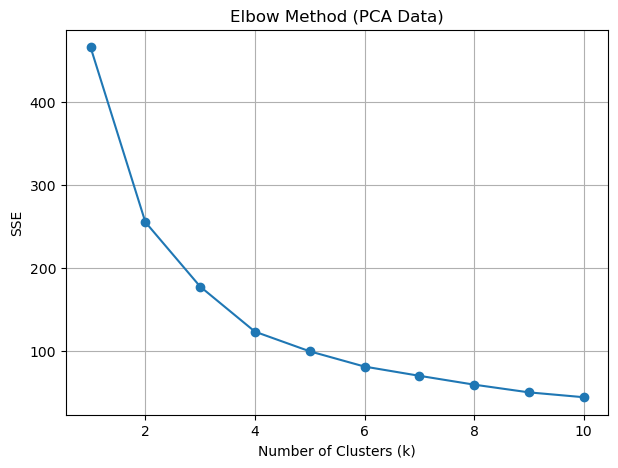

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_pca)
    sse.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method (PCA Data)')
plt.grid(True)
plt.show()

In [24]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# 결과 저장
X_pca_df['cluster'] = clusters

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [25]:
# KMeans 클러스터링 결과 시각화

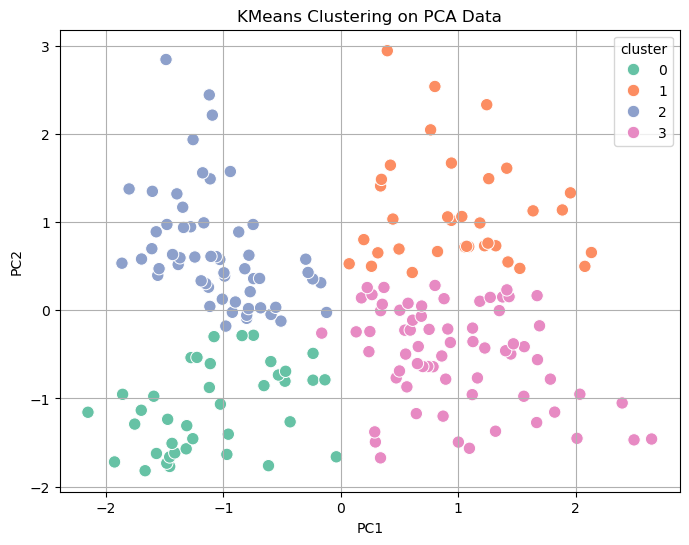

In [26]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    s=80
)

plt.title('KMeans Clustering on PCA Data')
plt.grid(True)
plt.show()

# 젠더 제외하고 진행하기

Explained Variance Ratio: [0.44266167 0.33308378]
Total Explained Variance: 0.7757454566976747


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

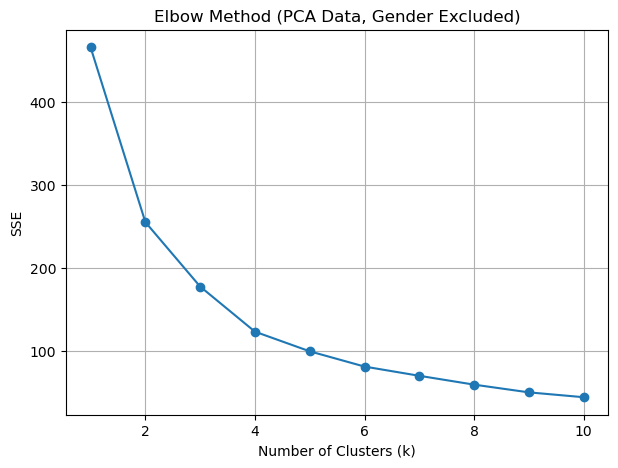

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


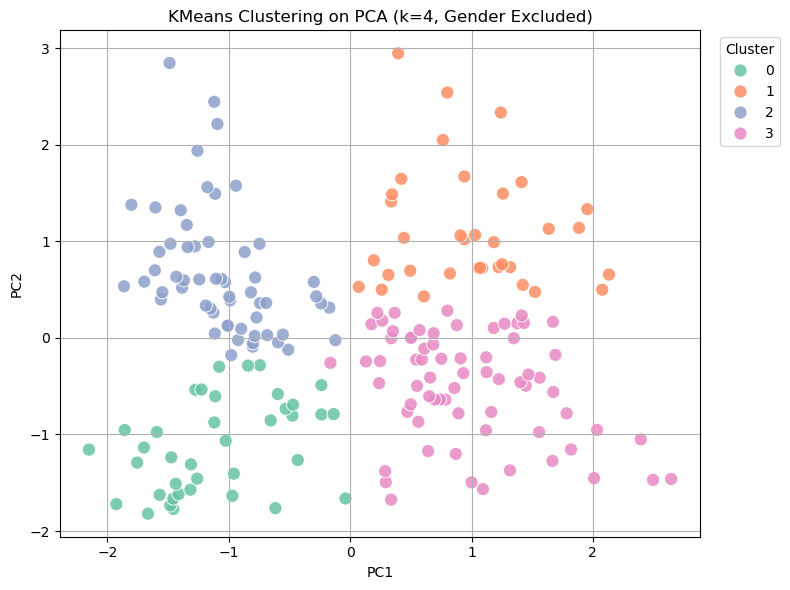

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Gender 제외: 연속형 3개만 사용
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

# 2) 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) PCA 2차원
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

# 4) 엘보우 (PCA 데이터 기준)
sse = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_pca)
    sse.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(k_range), sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method (PCA Data, Gender Excluded)')
plt.grid(True)
plt.show()

# 5) KMeans 
k = 4
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
pca_df['cluster'] = kmeans.fit_predict(X_pca)

# 6) 시각화 (seaborn)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    s=90,
    alpha=0.85
)
plt.title(f'KMeans Clustering on PCA (k={k}, Gender Excluded)')
plt.grid(True)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

| 클러스터 | 고객 특성           | 심리/행동 추정       | 추천 프로모션 전략                                        | KPI                |
| ---- | --------------- | -------------- | ------------------------------------------------- | ------------------ |
| 0    | 젊고 소득 낮지만 소비 적극 | 트렌드 민감, 감성 소비  | 🔥 한정판, SNS 연계 이벤트<br>🎟 포인트 적립 강화<br>💬 인플루언서 협업 | 객단가 상승률<br>재방문율    |
| 1    | 고소득 저소비         | 보수적, 구매 필요성 낮음 | 🎁 프리미엄 체험 초대<br>💳 VIP 전용 할인 쿠폰<br>🧠 개인화 추천 메일  | 전환율<br>고가상품 매출     |
| 2    | 고소득 고소비         | 브랜드 충성도 높음     | 💎 멤버십 등급제 강화<br>🎉 신제품 선공개<br>🎟 전용 라운지 혜택       | LTV<br>구매 빈도       |
| 3    | 저소득 저소비         | 가격 민감          | 🛒 묶음 할인<br>💰 쿠폰 중심 마케팅<br>📉 저가 라인 강조           | 프로모션 반응률<br>매출 안정성 |


In [28]:
cluster_result = df.copy()
cluster_result['cluster'] = pca_df['cluster']

cluster_summary = cluster_result.groupby('cluster')[['Age',
                                                      'Annual Income (k$)',
                                                      'Spending Score (1-100)']].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,-0.950531,-1.066012,0.671613
1,0.203510,1.056094,-1.277784
2,-0.635135,0.707135,0.798787
3,0.954133,-0.543024,-0.393167


# 실루엣 점수

In [29]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np

labels = pca_df['cluster']

sil_score = silhouette_score(X_pca, labels)
print("Silhouette Score:", round(sil_score, 4))

Silhouette Score: 0.4209


In [30]:
sample_silhouette = silhouette_samples(X_pca, labels)
pca_df['silhouette'] = sample_silhouette

cluster_silhouette = pca_df.groupby('cluster')['silhouette'].mean()
cluster_silhouette

cluster
0    0.458953
1    0.386279
2    0.469848
3    0.376443
Name: silhouette, dtype: float64

In [31]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_scaled)   # PCA 없이
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.4f}")

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

k=2, silhouette=0.3355
k=3, silhouette=0.3578
k=4, silhouette=0.4040
k=5, silhouette=0.4166
k=6, silhouette=0.4274


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


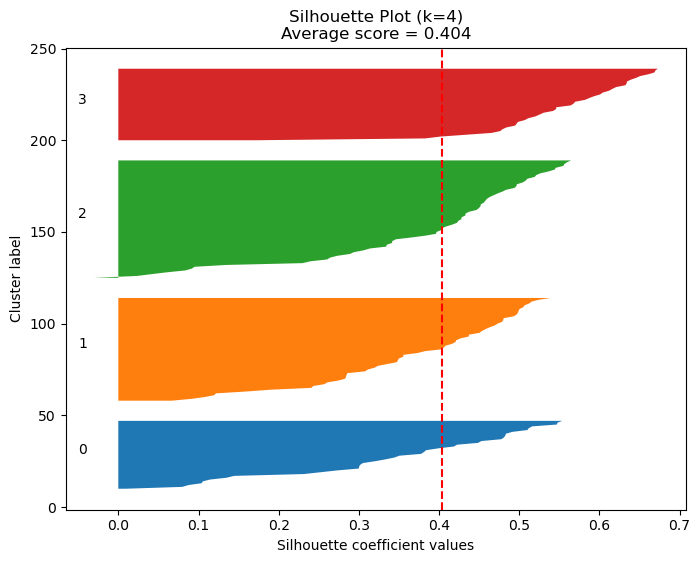

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans

# k 설정
k = 4

kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels = kmeans.fit_predict(X_scaled)

silhouette_avg = silhouette_score(X_scaled, labels)
sample_silhouette_values = silhouette_samples(X_scaled, labels)

fig, ax = plt.subplots(figsize=(8,6))

y_lower = 10

for i in range(k):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0,
                     ith_cluster_silhouette_values)

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="red", linestyle="--")
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Cluster label")
ax.set_title(f"Silhouette Plot (k={k})\nAverage score = {round(silhouette_avg,4)}")

plt.show()

# income, spending score만 사용

In [33]:
X2 = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X2_scaled)
    score = silhouette_score(X2_scaled, labels)
    print(k, score)

2 0.28640637225274423
3 0.46658474419000145
4 0.49390692375131984
5 0.5546571631111091
6 0.5377141165734254


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

In [34]:
from sklearn.cluster import KMeans

k = 5

kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels = kmeans.fit_predict(X_scaled)

pca_df['cluster'] = labels

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


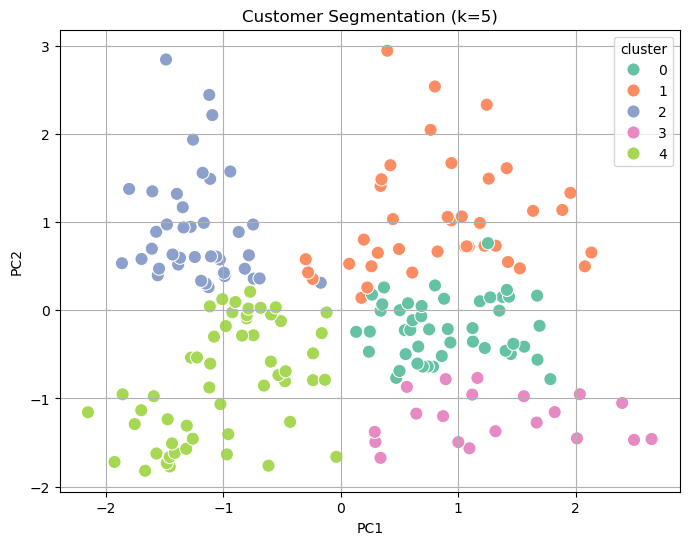

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    s=90
)

plt.title('Customer Segmentation (k=5)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)

plt.show()

In [36]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", round(sil_score,4))

Silhouette Score: 0.4166


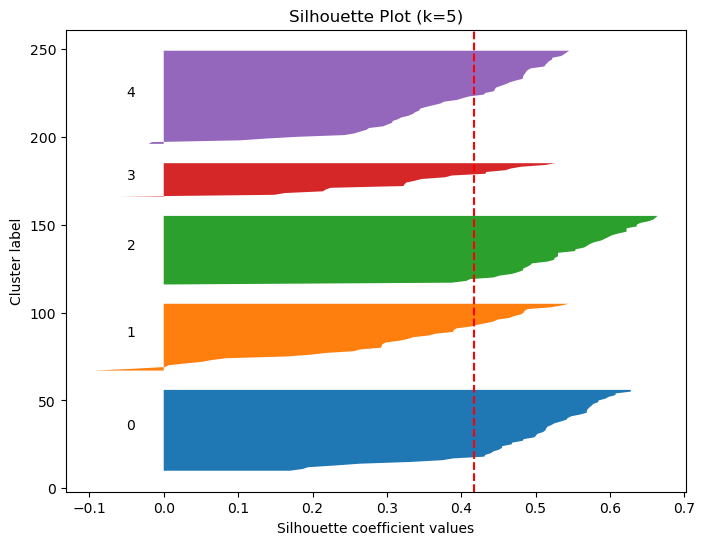

In [37]:
from sklearn.metrics import silhouette_samples
import numpy as np

sample_silhouette = silhouette_samples(X_scaled, labels)

fig, ax = plt.subplots(figsize=(8,6))

y_lower = 10

for i in range(k):
    
    ith_cluster_silhouette = sample_silhouette[labels == i]
    ith_cluster_silhouette.sort()
    
    size_cluster = ith_cluster_silhouette.shape[0]
    y_upper = y_lower + size_cluster
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0,
                     ith_cluster_silhouette)
    
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color="red", linestyle="--")

ax.set_title(f"Silhouette Plot (k={k})")
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Cluster label")

plt.show()

# 개선버전 

In [38]:
X_basic = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X_basic.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_basic_scaled = scaler.fit_transform(X_basic)

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

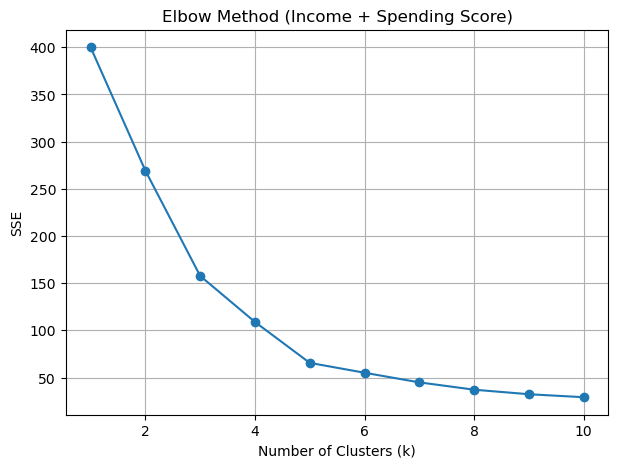

In [40]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_basic_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method (Income + Spending Score)')
plt.grid(True)
plt.show()

In [41]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_basic_scaled)
    score = silhouette_score(X_basic_scaled, labels)
    print(f'k={k}, silhouette={score:.4f}')

k=2, silhouette=0.2864
k=3, silhouette=0.4666
k=4, silhouette=0.4939
k=5, silhouette=0.5547
k=6, silhouette=0.5377


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

In [42]:
k = 5

kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels = kmeans.fit_predict(X_basic_scaled)

cluster_df = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()
cluster_df['cluster'] = labels

cluster_df.head()

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Annual Income (k$),Spending Score (1-100),cluster
0,-1.738999,-0.434801,3
1,-1.738999,1.195704,4
2,-1.700830,-1.715913,3
3,-1.700830,1.040418,4
4,-1.662660,-0.395980,3


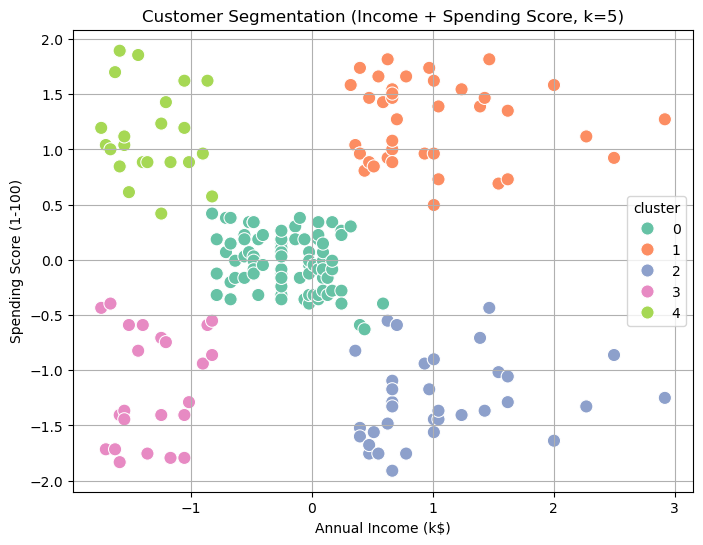

In [43]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=cluster_df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='cluster',
    palette='Set2',
    s=90
)

plt.title('Customer Segmentation (Income + Spending Score, k=5)')
plt.grid(True)
plt.show()

In [44]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centers_df['cluster'] = range(k)
centers_df

,Annual Income (k$),Spending Score (1-100),cluster
0,-0.200913,-0.026456,0
1,0.991583,1.239503,1
2,1.055003,-1.284439,2
3,-1.307519,-1.136965,3
4,-1.329545,1.132178,4


| 세그먼트          | 중심 특성        | 고객 해석                                     | 추천 대응 전략                                                          | 우선 KPI                    |
| ------------- | ------------ | ----------------------------------------- | ----------------------------------------------------------------- | ------------------------- |
| **Cluster 0** | 소득 보통, 지출 보통 | **대중형 균형 고객층**. 특정 방향으로 치우치지 않은 일반 고객군    | 기본 프로모션, 시즌 캠페인, 재방문 유도 쿠폰 운영. 과도한 할인보다 **적정 혜택 + 구매 빈도 증가**가 중요  | 재방문율, 객단가, 월별 구매 빈도       |
| **Cluster 1** | 소득 높음, 지출 높음 | **핵심 VIP 고객층**. 구매력과 소비 성향이 모두 높음         | 프리미엄 상품 추천, 멤버십 강화, 한정판/선런칭, 전용 혜택 제공. 이탈 방지가 핵심                  | LTV, VIP 유지율, 고마진 상품 매출   |
| **Cluster 2** | 소득 높음, 지출 낮음 | **잠재 전환 고객층**. 살 여력은 충분하지만 현재 소비가 활발하지 않음 | 개인화 추천, 체험형 프로모션, 첫 구매 유도 쿠폰, 카테고리 진입 장벽 낮추기. “왜 안 사는지”를 푸는 전략 필요 | 전환율, 첫 구매율, 프로모션 반응률      |
| **Cluster 3** | 소득 낮음, 지출 낮음 | **저관여·가격민감 고객층**. 적극적인 지출 성향이 낮음          | 저가 상품, 묶음 할인, 쿠폰 중심 운영. 고비용 CRM보다 **자동화된 효율 마케팅**이 적합             | 쿠폰 사용률, 저가라인 매출, 휴면률      |
| **Cluster 4** | 소득 낮음, 지출 높음 | **가성비 반응형 소비 고객층**. 소득은 낮지만 소비 의지가 높음     | 타임세일, 한정 할인, SNS/이벤트형 캠페인, 소액 고빈도 구매 유도. 충동구매 트리거 설계가 효과적         | 프로모션 반응률, 구매 빈도, 장바구니 전환율 |
